In [1]:
from dataclasses import replace
from pathlib import Path
import importlib

import numpy as np
from IPython.display import Image, display

import ntk_jax as analysis
analysis = importlib.reload(analysis)
import jax

MODULE_PATH = Path(analysis.__file__).resolve()
ROOT = MODULE_PATH.parent
print(f"Analysis module: {MODULE_PATH}")
print(f"Training/Jacobian dtype: {analysis.TRAIN_DTYPE}")
print(f"Utilities: {analysis.VANILLA_UTILITY_PATH.name}, {analysis.ADAPTIVE_UTILITY_PATH.name}, {analysis.TAL_UTILITY_PATH.name}")

Analysis module: /home/DG21210022/Amon/tal/burgers/ntk_jax.py
Training/Jacobian dtype: <class 'jax.numpy.float32'>
Utilities: Utilities_pinn_burgers1d_statistic.py, Utilities_pinn_adsamp_burgers1d.py, Utilities_talpinn_burgers1d_statistic.py


In [2]:
DATA_PATH = ROOT / "burgers_godunov.mat"
OUTPUT_PREFIX = ROOT / "burgers1d_reference_mechanism"
QUICK_TEST = False

config = analysis.ExperimentConfig(
    seed=44,
    nu=1.0e-4,
    coordinate_iters=10_000,
    train_iters=10_000,
    ntk_pde_points=1_000,
    ntk_ic_points=100,
    ntk_bc_points=100,
)

if QUICK_TEST:
    config = replace(
        config,
        coordinate_iters=2,
        coordinate_batch_size=32,
        coordinate_eval_every=1,
        train_iters=2,
        train_pde_points=16,
        train_ic_points=8,
        train_bc_points=8,
        train_eval_every=1,
        ntk_pde_points=8,
        ntk_ic_points=4,
        ntk_bc_points=4,
        ntk_chunk_size=8,
        residual_time_stride=8,
        residual_space_stride=8,
        residual_chunk_size=256,
        plot_sample_points=256,
    )

analysis.validate_config(config)
if not DATA_PATH.is_file():
    raise FileNotFoundError(f"Missing reference data: {DATA_PATH}")

config

ExperimentConfig(seed=44, nu=0.0001, time_stride=2, space_stride=2, hidden_width=40, hidden_depth=2, fourier_dim=20, optimizer='soap', learning_rate=0.003, weight_decay=0.01, w_ic=10.0, w_bc=10.0, coordinate_iters=10000, coordinate_batch_size=10000, coordinate_eval_every=1000, train_iters=10000, train_pde_points=10000, train_ic_points=1000, train_bc_points=1000, train_eval_every=100, max_runtime=10000.0, ntk_pde_points=1000, ntk_ic_points=100, ntk_bc_points=100, ntk_chunk_size=128, residual_time_stride=2, residual_space_stride=2, residual_chunk_size=1024, plot_sample_points=4000)

In [3]:
# 每一步使用固定且独立的随机键，重新运行单个单元格不会改变其他步骤。
keys = analysis.create_experiment_keys(config.seed)
list(keys)

['vanilla_init',
 'adaptive_init',
 'tal_init',
 'coordinate_init',
 'coordinate_train',
 'ntk',
 'train_vanilla',
 'train_adaptive',
 'train_tal',
 'residual']

In [4]:
geometry = analysis.prepare_reference_geometry(DATA_PATH, config)

mesh_summary = {
    "reference_shape": tuple(geometry["U"].shape),
    "xi_shape": tuple(geometry["Xi_of_x"].shape),
    "adaptive_mesh_shape": tuple(geometry["X_adapt"].shape),
    "mesh_seconds": geometry["mesh_seconds"],
    "x_range": (float(geometry["X"][0, 0]), float(geometry["X"][0, -1])),
    "t_range": (float(geometry["T"][0, 0]), float(geometry["T"][-1, 0])),
}
mesh_summary

{'reference_shape': (513, 513),
 'xi_shape': (513, 513),
 'adaptive_mesh_shape': (513, 513),
 'mesh_seconds': 0.495643462985754,
 'x_range': (0.0, 1.0),
 't_range': (0.0, 1.0)}

In [5]:
models, initial_params = analysis.initialize_models(
    config,
    keys["vanilla_init"],
    keys["adaptive_init"],
    keys["tal_init"],
    keys["coordinate_init"],
)

def count_parameters(params):
    return int(
        sum(
            np.asarray(leaf).size
            for leaf in jax.tree_util.tree_leaves(params)
        )
    )

{
    "Vanilla PINN parameters": count_parameters(
        initial_params["vanilla"]
    ),
    "Adaptive PINN parameters": count_parameters(
        initial_params["adaptive"]
    ),
    "TAL-PINN parameters": count_parameters(
        initial_params["tal"]
    ),
    "Coordinate network parameters": count_parameters(
        initial_params["coordinate"]
    ),
}

{'Vanilla PINN parameters': 2581,
 'Adaptive PINN parameters': 2581,
 'TAL-PINN parameters': 2601,
 'Coordinate network parameters': 2581}

In [6]:
coordinate_params, coordinate_fn, coordinate_metrics, coordinate_seconds = (
    analysis.fit_coordinate_network(
        config,
        models["coordinate"],
        initial_params["coordinate"],
        geometry,
        keys["coordinate_train"],
    )
)

coordinate_metrics | {"training_seconds": coordinate_seconds}

[Coordinate] JIT warm-up finished.
[Coordinate] iter = 01000, time = 2.21s, batch loss = 3.42e-05, full mse = 3.04e-05
[Coordinate] iter = 02000, time = 4.17s, batch loss = 2.89e-06, full mse = 2.64e-06
[Coordinate] iter = 03000, time = 6.11s, batch loss = 2.02e-06, full mse = 2.55e-06
[Coordinate] iter = 04000, time = 8.05s, batch loss = 2.56e-06, full mse = 2.12e-06
[Coordinate] iter = 05000, time = 9.99s, batch loss = 1.35e-06, full mse = 1.09e-06
[Coordinate] iter = 06000, time = 11.92s, batch loss = 1.14e-06, full mse = 1.52e-06
[Coordinate] iter = 07000, time = 13.86s, batch loss = 1.93e-06, full mse = 9.35e-07
[Coordinate] iter = 08000, time = 15.82s, batch loss = 7.23e-07, full mse = 1.77e-06
[Coordinate] iter = 09000, time = 17.79s, batch loss = 1.01e-06, full mse = 9.26e-07
[Coordinate] iter = 10000, time = 19.74s, batch loss = 5.79e-07, full mse = 6.24e-07


{'mse': 6.23644950792368e-07,
 'max_abs_error': 0.016614198684692383,
 'min_xi_x': 0.04019714519381523,
 'max_xi_x': 63.78315734863281,
 'training_seconds': 25.667342334985733}

In [7]:
minibatch_functions = analysis.build_minibatch_functions(
    geometry,
    coordinate_fn,
)

ntk_results = analysis.compute_initial_ntks(
    config,
    models,
    initial_params,
    minibatch_functions,
    keys["ntk"],
)

{
    name: analysis.spectral_summary(result["eigen_total"])
    for name, result in ntk_results.items()
}

Computing vanilla initial NTK spectra ...
[vanilla] NTK=16.40s, trace=7.867e+03, effective rank=14.05
Computing adaptive initial NTK spectra ...
[adaptive] NTK=8.85s, trace=5.834e+03, effective rank=25.32
Computing tal initial NTK spectra ...
[tal] NTK=13.62s, trace=5.192e+04, effective rank=17.20


{'vanilla': {'trace': 7866.52307144602,
  'effective_rank': 14.05249434183826,
  'numerical_rank': 800.0,
  'condition': 60051275324.45678},
 'adaptive': {'trace': 5834.37208567664,
  'effective_rank': 25.31558391374912,
  'numerical_rank': 843.0,
  'condition': 816716651588.5924},
 'tal': {'trace': 51915.07203207123,
  'effective_rank': 17.198258358207756,
  'numerical_rank': 984.0,
  'condition': 725766081195.5131}}

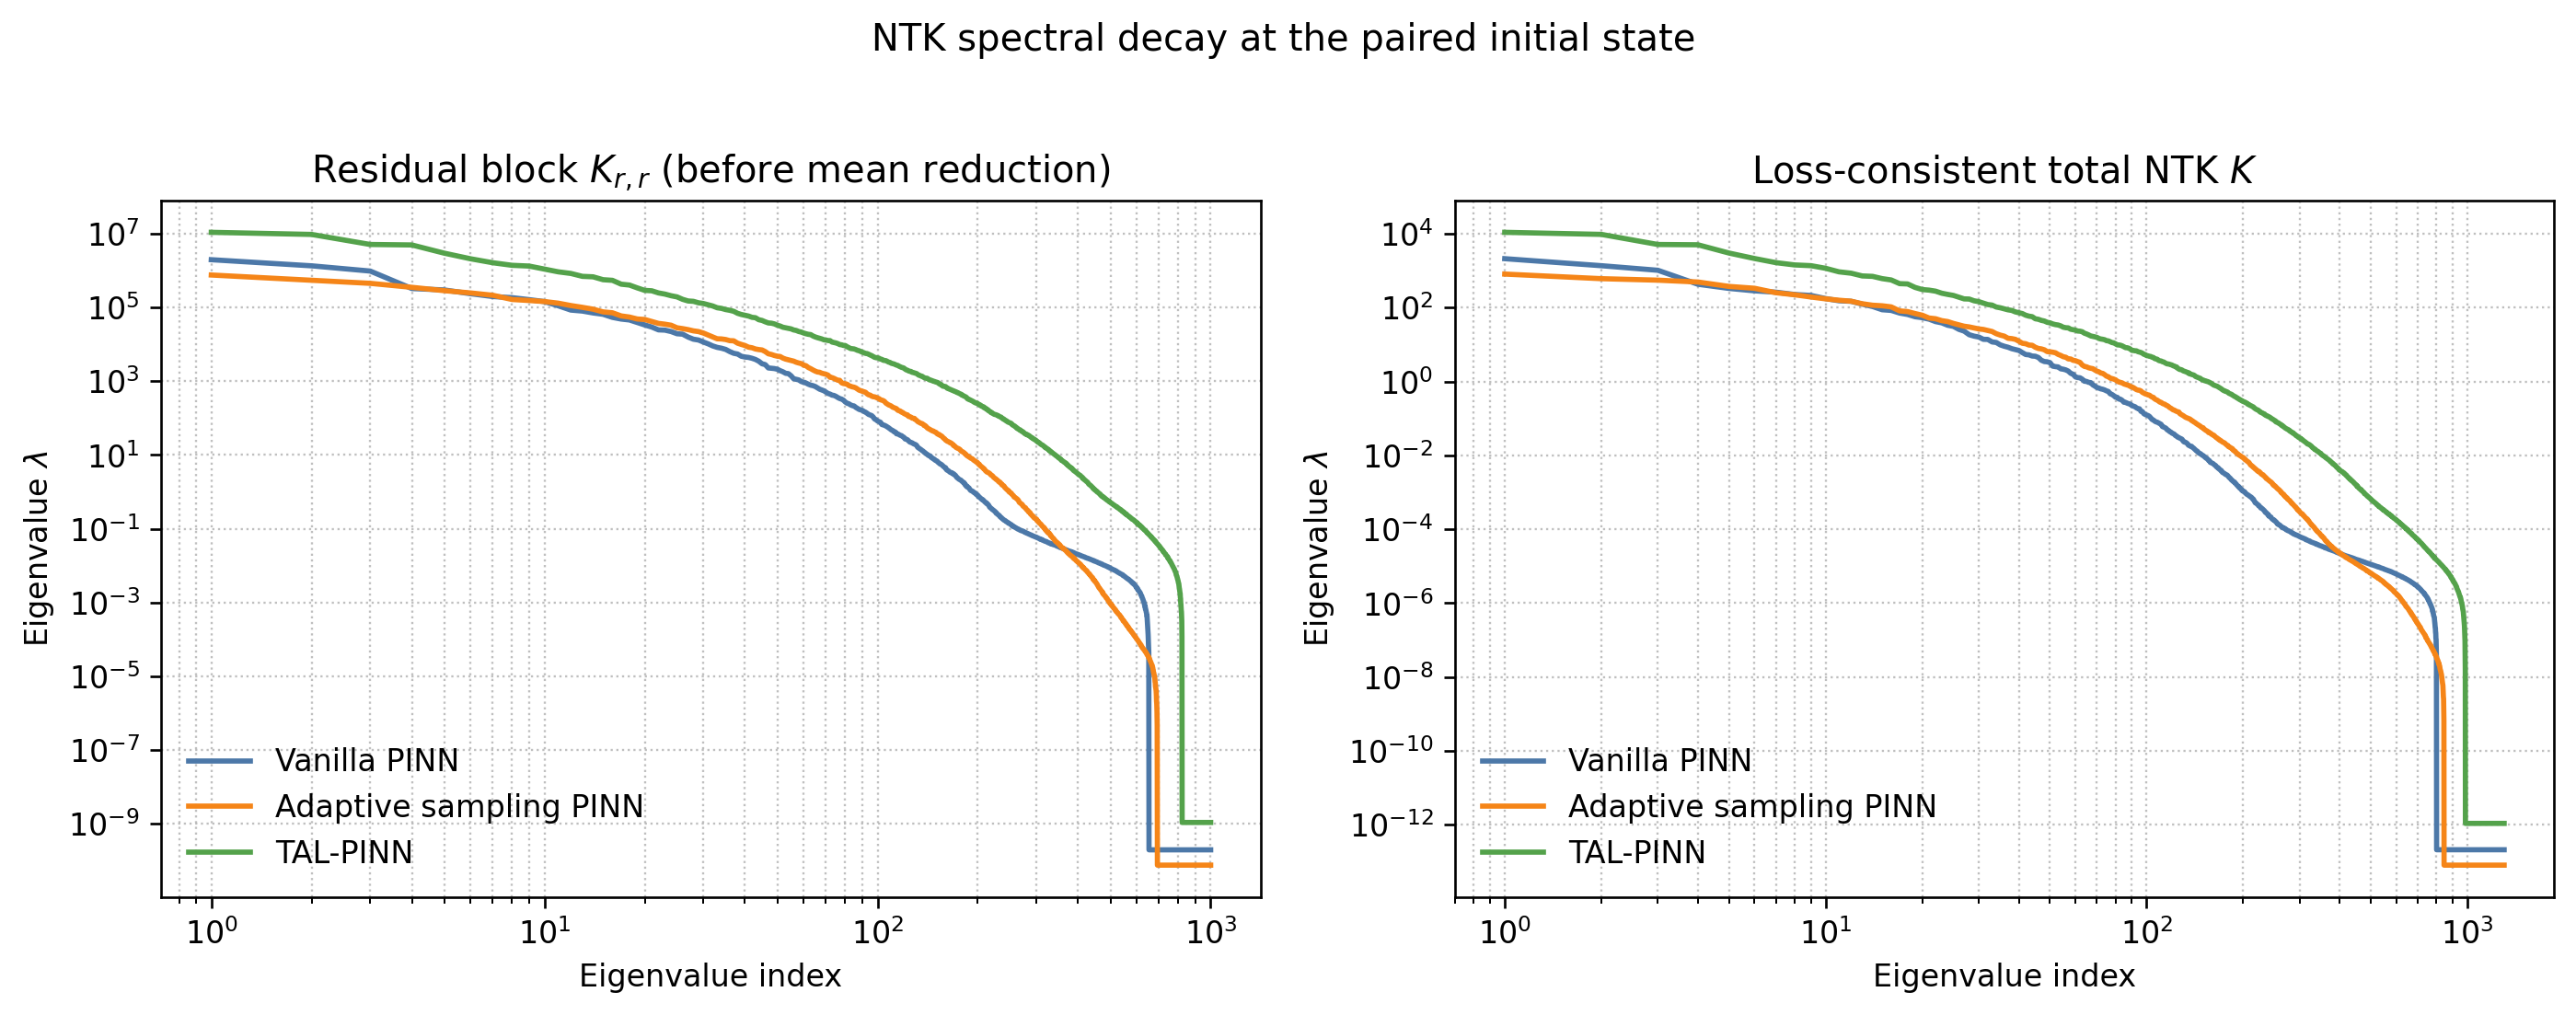

In [8]:
# NTK 计算完成后即可单独查看谱，不必等待三种训练结束。
ntk_plot_data = {}
for name, result in ntk_results.items():
    ntk_plot_data[f"{name}_eigen_residual_unscaled"] = result["eigen_residual_unscaled"]
    ntk_plot_data[f"{name}_eigen_total"] = result["eigen_total"]

ntk_figure_paths = analysis.plot_ntk_spectra(ntk_plot_data, OUTPUT_PREFIX)
display(Image(filename=str(ntk_figure_paths[1])))

In [9]:
test_problem = analysis.prepare_test_problem(models, geometry, coordinate_fn)
print(
    f"Test grid: Nt={test_problem['nt']}, Nx={test_problem['nx']}; "
    f"excluded interface x={test_problem['interface_x']:.8f}, "
    f"index={test_problem['interface_index']}"
)

optimizer_vanilla = analysis.make_optimizer(config)
optimizer_adaptive = analysis.make_optimizer(config)
optimizer_tal = analysis.make_optimizer(config)

# 二维与三维参数各检查一次；adaptive 与 vanilla 的参数树完全相同。
analysis.check_optimizer_dtype(
    optimizer_vanilla,
    initial_params["vanilla"],
    "2D solution parameters",
)
analysis.check_optimizer_dtype(
    optimizer_adaptive,
    initial_params["adaptive"],
    "2D solution parameters",
)
analysis.check_optimizer_dtype(
    optimizer_tal,
    initial_params["tal"],
    "3D TAL parameters",
)

Test grid: Nt=513, Nx=513; excluded interface x=0.50000000, index=256


In [10]:
training_kwargs = {
    "nu": config.nu,
    "max_iters": config.train_iters,
    "pts_pde": config.train_pde_points,
    "pts_ics": config.train_ic_points,
    "pts_bcs": config.train_bc_points,
    "max_runtime": config.max_runtime,
    "eval_every": config.train_eval_every,
}

training_kwargs

{'nu': 0.0001,
 'max_iters': 10000,
 'pts_pde': 10000,
 'pts_ics': 1000,
 'pts_bcs': 1000,
 'max_runtime': 10000.0,
 'eval_every': 100}

In [11]:
vanilla_params, vanilla_key_out, vanilla_history = (
    analysis.vanilla_utils.train_pde_stage(
        stage_name="Vanilla PINN",
        pde_params=initial_params["vanilla"],
        pde_optimizer=optimizer_vanilla,
        pde_loss_grad_fn=analysis.vanilla_utils.create_pde_loss_grad_fn(
            models["solution_2d"],
            w_ic=config.w_ic,
            w_bc=config.w_bc,
        ),
        pde_minibatch_fn=minibatch_functions["vanilla"],
        eval_fn=test_problem["eval_2d"],
        test_inputs=test_problem["inputs_2d"],
        test_labels=test_problem["labels"],
        key=keys["train_vanilla"],
        **training_kwargs,
    )
)

[Vanilla PINN] JIT warm-up finished.
[Vanilla PINN] iter = 00000, time = 0.00s | mse = 1.27e+00, rl2 = 2.27e+00
[Vanilla PINN] iter = 00100, time = 0.34s, loss = 5.96e-01 | mse = 6.18e-02, rl2 = 5.02e-01
[Vanilla PINN] iter = 00200, time = 0.64s, loss = 5.33e-01 | mse = 5.06e-02, rl2 = 4.54e-01
[Vanilla PINN] iter = 00300, time = 0.95s, loss = 5.00e-01 | mse = 4.67e-02, rl2 = 4.36e-01
[Vanilla PINN] iter = 00400, time = 1.25s, loss = 4.68e-01 | mse = 4.36e-02, rl2 = 4.22e-01
[Vanilla PINN] iter = 00500, time = 1.56s, loss = 5.01e-01 | mse = 4.21e-02, rl2 = 4.14e-01
[Vanilla PINN] iter = 00600, time = 1.86s, loss = 4.79e-01 | mse = 4.11e-02, rl2 = 4.09e-01
[Vanilla PINN] iter = 00700, time = 2.17s, loss = 4.78e-01 | mse = 4.04e-02, rl2 = 4.06e-01
[Vanilla PINN] iter = 00800, time = 2.48s, loss = 4.91e-01 | mse = 3.97e-02, rl2 = 4.02e-01
[Vanilla PINN] iter = 00900, time = 2.78s, loss = 4.74e-01 | mse = 3.93e-02, rl2 = 4.00e-01
[Vanilla PINN] iter = 01000, time = 3.07s, loss = 4.76e-01 |

In [12]:
adaptive_params, adaptive_key_out, adaptive_history = (
    analysis.adaptive_utils.train_pde_stage(
        stage_name="Adaptive-sampling PINN",
        pde_params=initial_params["adaptive"],
        pde_optimizer=optimizer_adaptive,
        pde_loss_grad_fn=analysis.adaptive_utils.create_pde_loss_grad_fn(
            models["solution_2d"],
            w_ic=config.w_ic,
            w_bc=config.w_bc,
        ),
        pde_minibatch_fn=minibatch_functions["adaptive"],
        eval_fn=test_problem["eval_2d"],
        test_inputs=test_problem["inputs_2d"],
        test_labels=test_problem["labels"],
        key=keys["train_adaptive"],
        **training_kwargs,
    )
)

[Adaptive-sampling PINN] JIT warm-up finished.
[Adaptive-sampling PINN] iter = 00000, time = 0.00s | mse = 5.15e-01, rl2 = 1.45e+00
[Adaptive-sampling PINN] iter = 00100, time = 0.36s, loss = 5.78e-01 | mse = 5.64e-02, rl2 = 4.79e-01
[Adaptive-sampling PINN] iter = 00200, time = 0.70s, loss = 5.06e-01 | mse = 4.81e-02, rl2 = 4.43e-01
[Adaptive-sampling PINN] iter = 00300, time = 1.03s, loss = 4.86e-01 | mse = 4.49e-02, rl2 = 4.28e-01
[Adaptive-sampling PINN] iter = 00400, time = 1.37s, loss = 4.78e-01 | mse = 4.29e-02, rl2 = 4.18e-01
[Adaptive-sampling PINN] iter = 00500, time = 1.70s, loss = 4.87e-01 | mse = 4.23e-02, rl2 = 4.15e-01
[Adaptive-sampling PINN] iter = 00600, time = 2.04s, loss = 4.67e-01 | mse = 3.95e-02, rl2 = 4.01e-01
[Adaptive-sampling PINN] iter = 00700, time = 2.37s, loss = 4.91e-01 | mse = 3.95e-02, rl2 = 4.01e-01
[Adaptive-sampling PINN] iter = 00800, time = 2.70s, loss = 4.83e-01 | mse = 3.96e-02, rl2 = 4.02e-01
[Adaptive-sampling PINN] iter = 00900, time = 3.04s,

In [13]:
tal_params, tal_key_out, tal_history = (
    analysis.tal_utils.train_pde_stage(
        stage_name="TAL-PINN",
        pde_params=initial_params["tal"],
        pde_optimizer=optimizer_tal,
        pde_loss_grad_fn=analysis.tal_utils.create_pde_loss_grad_fn(
            models["solution_3d"],
            w_ic=config.w_ic,
            w_bc=config.w_bc,
        ),
        pde_minibatch_fn=minibatch_functions["tal"],
        eval_fn=test_problem["eval_3d"],
        test_inputs=test_problem["inputs_3d"],
        test_labels=test_problem["labels"],
        key=keys["train_tal"],
        **training_kwargs,
    )
)

[TAL-PINN] JIT warm-up finished.
[TAL-PINN] iter = 00000, time = 0.00s | mse = 6.22e-01, rl2 = 1.59e+00
[TAL-PINN] iter = 00100, time = 0.37s, loss = 6.00e-01 | mse = 5.06e-02, rl2 = 4.54e-01
[TAL-PINN] iter = 00200, time = 0.73s, loss = 4.59e-01 | mse = 3.63e-02, rl2 = 3.84e-01
[TAL-PINN] iter = 00300, time = 1.08s, loss = 4.25e-01 | mse = 3.07e-02, rl2 = 3.53e-01
[TAL-PINN] iter = 00400, time = 1.44s, loss = 2.91e-01 | mse = 1.76e-02, rl2 = 2.68e-01
[TAL-PINN] iter = 00500, time = 1.79s, loss = 1.72e-01 | mse = 7.69e-03, rl2 = 1.77e-01
[TAL-PINN] iter = 00600, time = 2.15s, loss = 1.04e-01 | mse = 3.84e-03, rl2 = 1.25e-01
[TAL-PINN] iter = 00700, time = 2.51s, loss = 8.00e-02 | mse = 2.69e-03, rl2 = 1.05e-01
[TAL-PINN] iter = 00800, time = 2.86s, loss = 7.41e-02 | mse = 1.96e-03, rl2 = 8.95e-02
[TAL-PINN] iter = 00900, time = 3.22s, loss = 5.85e-02 | mse = 1.50e-03, rl2 = 7.81e-02
[TAL-PINN] iter = 01000, time = 3.57s, loss = 5.58e-02 | mse = 1.22e-03, rl2 = 7.04e-02
[TAL-PINN] iter 

In [14]:
final_params = {
    "vanilla": vanilla_params,
    "adaptive": adaptive_params,
    "tal": tal_params,
}
histories = {
    "vanilla": vanilla_history,
    "adaptive": adaptive_history,
    "tal": tal_history,
}

{name: int(history["iter"][-1]) for name, history in histories.items()}

{'vanilla': 10000, 'adaptive': 10000, 'tal': 10000}

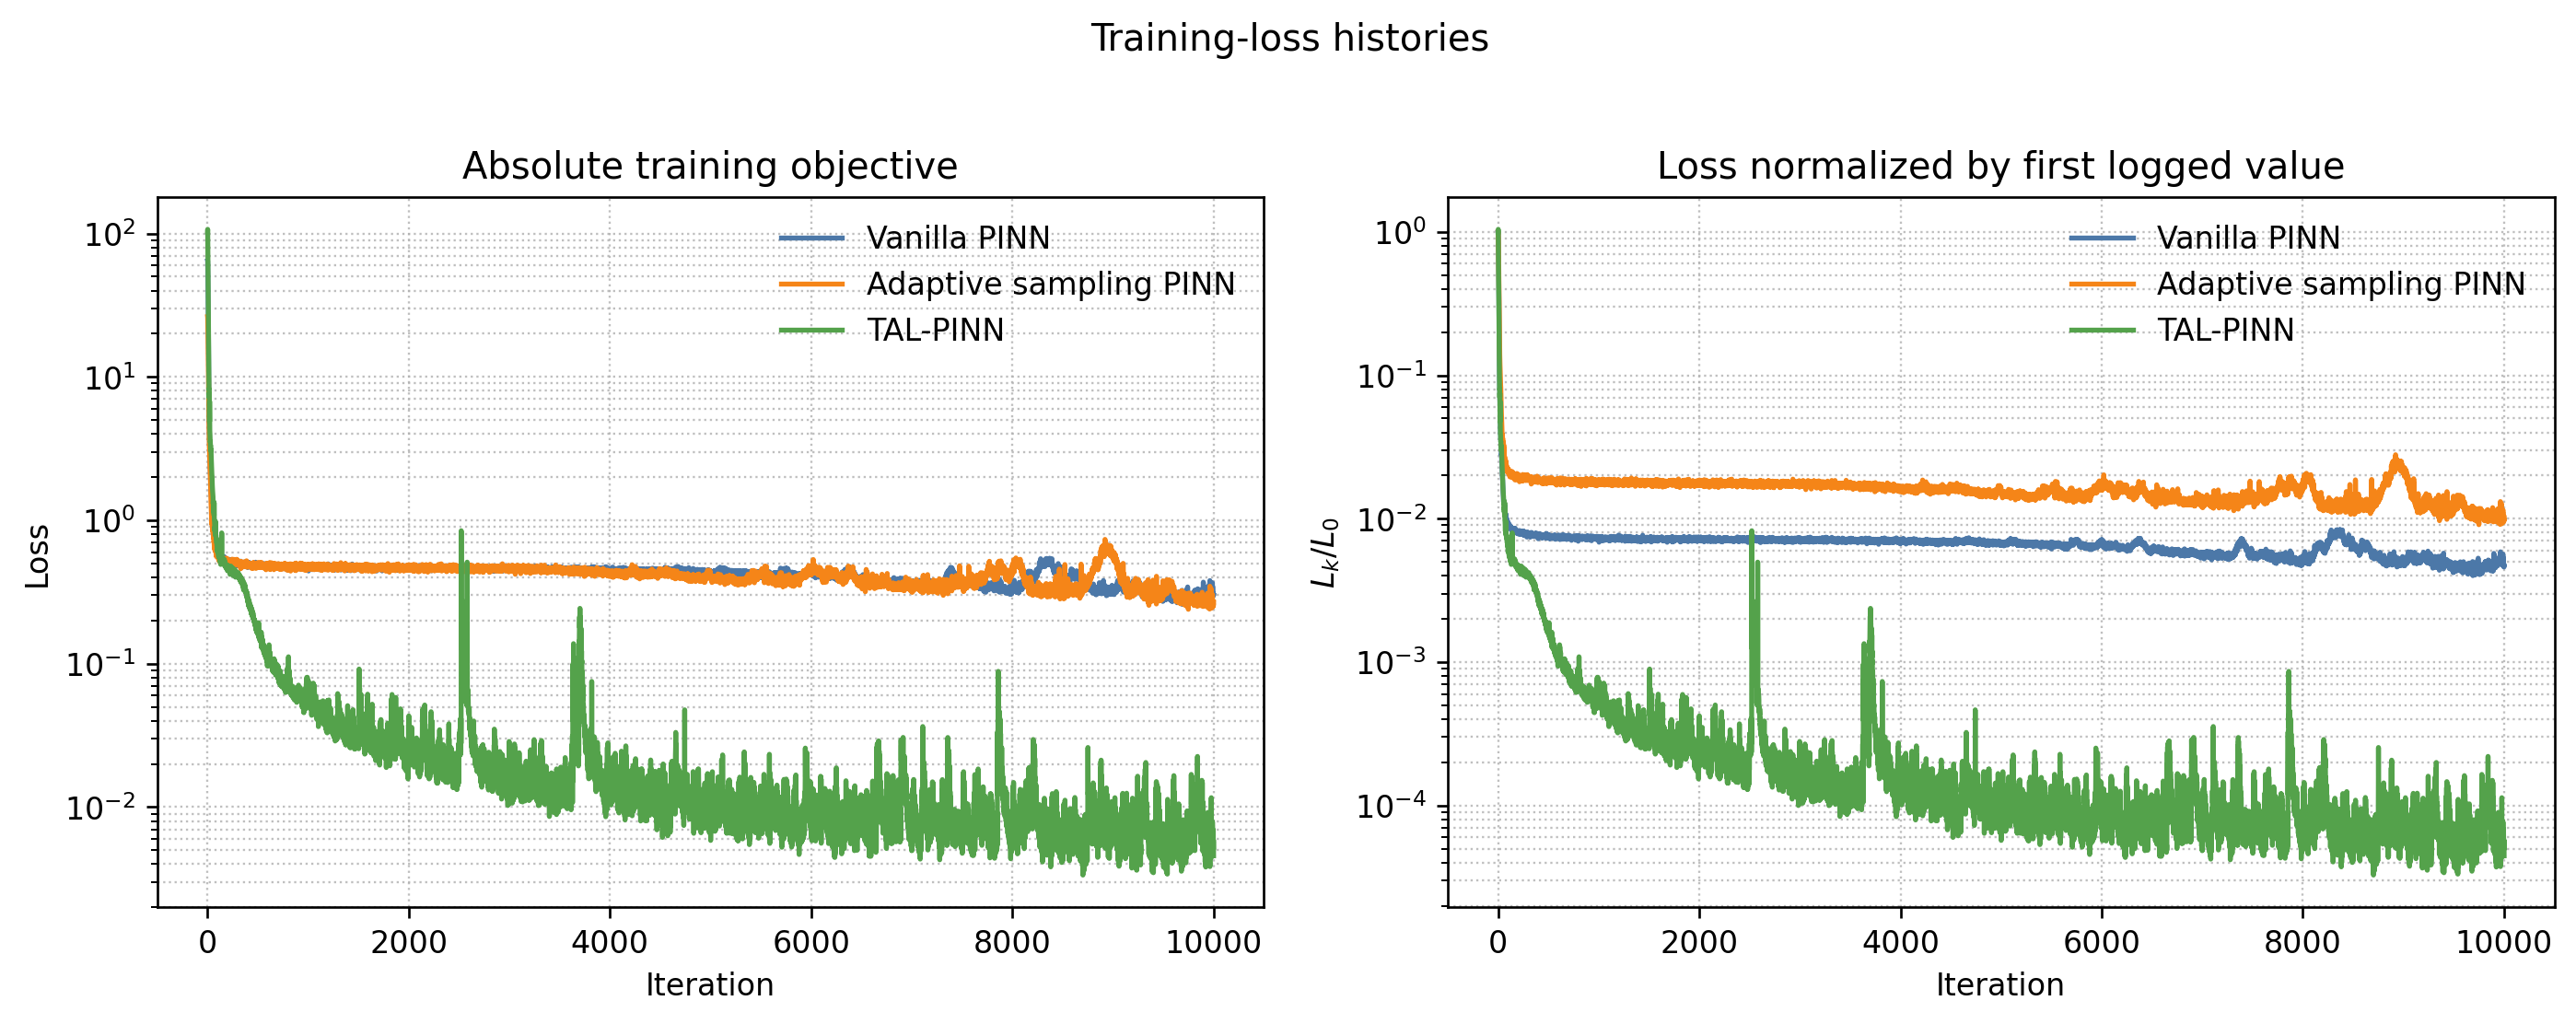

In [15]:
# 训练完成后先查看 loss history。
loss_plot_data = {}
for name, history in histories.items():
    loss_plot_data[f"{name}_iter"] = history["iter"]
    loss_plot_data[f"{name}_loss"] = history["loss"]

loss_figure_paths = analysis.plot_loss_histories(loss_plot_data, OUTPUT_PREFIX)
display(Image(filename=str(loss_figure_paths[1])))

In [16]:
residual_data = analysis.evaluate_final_residuals(
    config,
    models,
    coordinate_params,
    final_params,
    geometry,
    keys["residual"],
)

{
    name: {
        "rms": float(np.sqrt(np.mean(np.asarray(residual_data[f"{name}_final_residual"]) ** 2))),
        "max_abs": float(np.max(np.abs(np.asarray(residual_data[f"{name}_final_residual"])))),
    }
    for name in analysis.METHODS
}

Evaluating final residuals on (257, 257) physical grid ...


{'vanilla': {'rms': 0.4739276170730591, 'max_abs': 8.383033752441406},
 'adaptive': {'rms': 0.4500962495803833, 'max_abs': 9.119178771972656},
 'tal': {'rms': 0.05960699915885925, 'max_abs': 1.6109848022460938}}

In [17]:
export = analysis.flatten_analysis_data(
    config,
    geometry,
    ntk_results,
    histories,
    residual_data,
    coordinate_metrics,
    coordinate_seconds=coordinate_seconds,
)

metadata = analysis.build_analysis_metadata(
    config,
    geometry,
    ntk_results,
    coordinate_metrics,
    coordinate_seconds=coordinate_seconds,
)

checkpoint = analysis.build_checkpoint(
    coordinate_params,
    initial_params,
    final_params,
)

saved_paths = analysis.save_analysis_data(
    OUTPUT_PREFIX,
    export,
    metadata,
    checkpoint,
)
saved_paths

{'npz': PosixPath('/home/DG21210022/Amon/tal/burgers/burgers1d_reference_mechanism_analysis.npz'),
 'mat': PosixPath('/home/DG21210022/Amon/tal/burgers/burgers1d_reference_mechanism_analysis.mat'),
 'metadata': PosixPath('/home/DG21210022/Amon/tal/burgers/burgers1d_reference_mechanism_metadata.json'),
 'checkpoint': PosixPath('/home/DG21210022/Amon/tal/burgers/burgers1d_reference_mechanism_models.msgpack')}

burgers1d_reference_mechanism_sampling_distribution.png


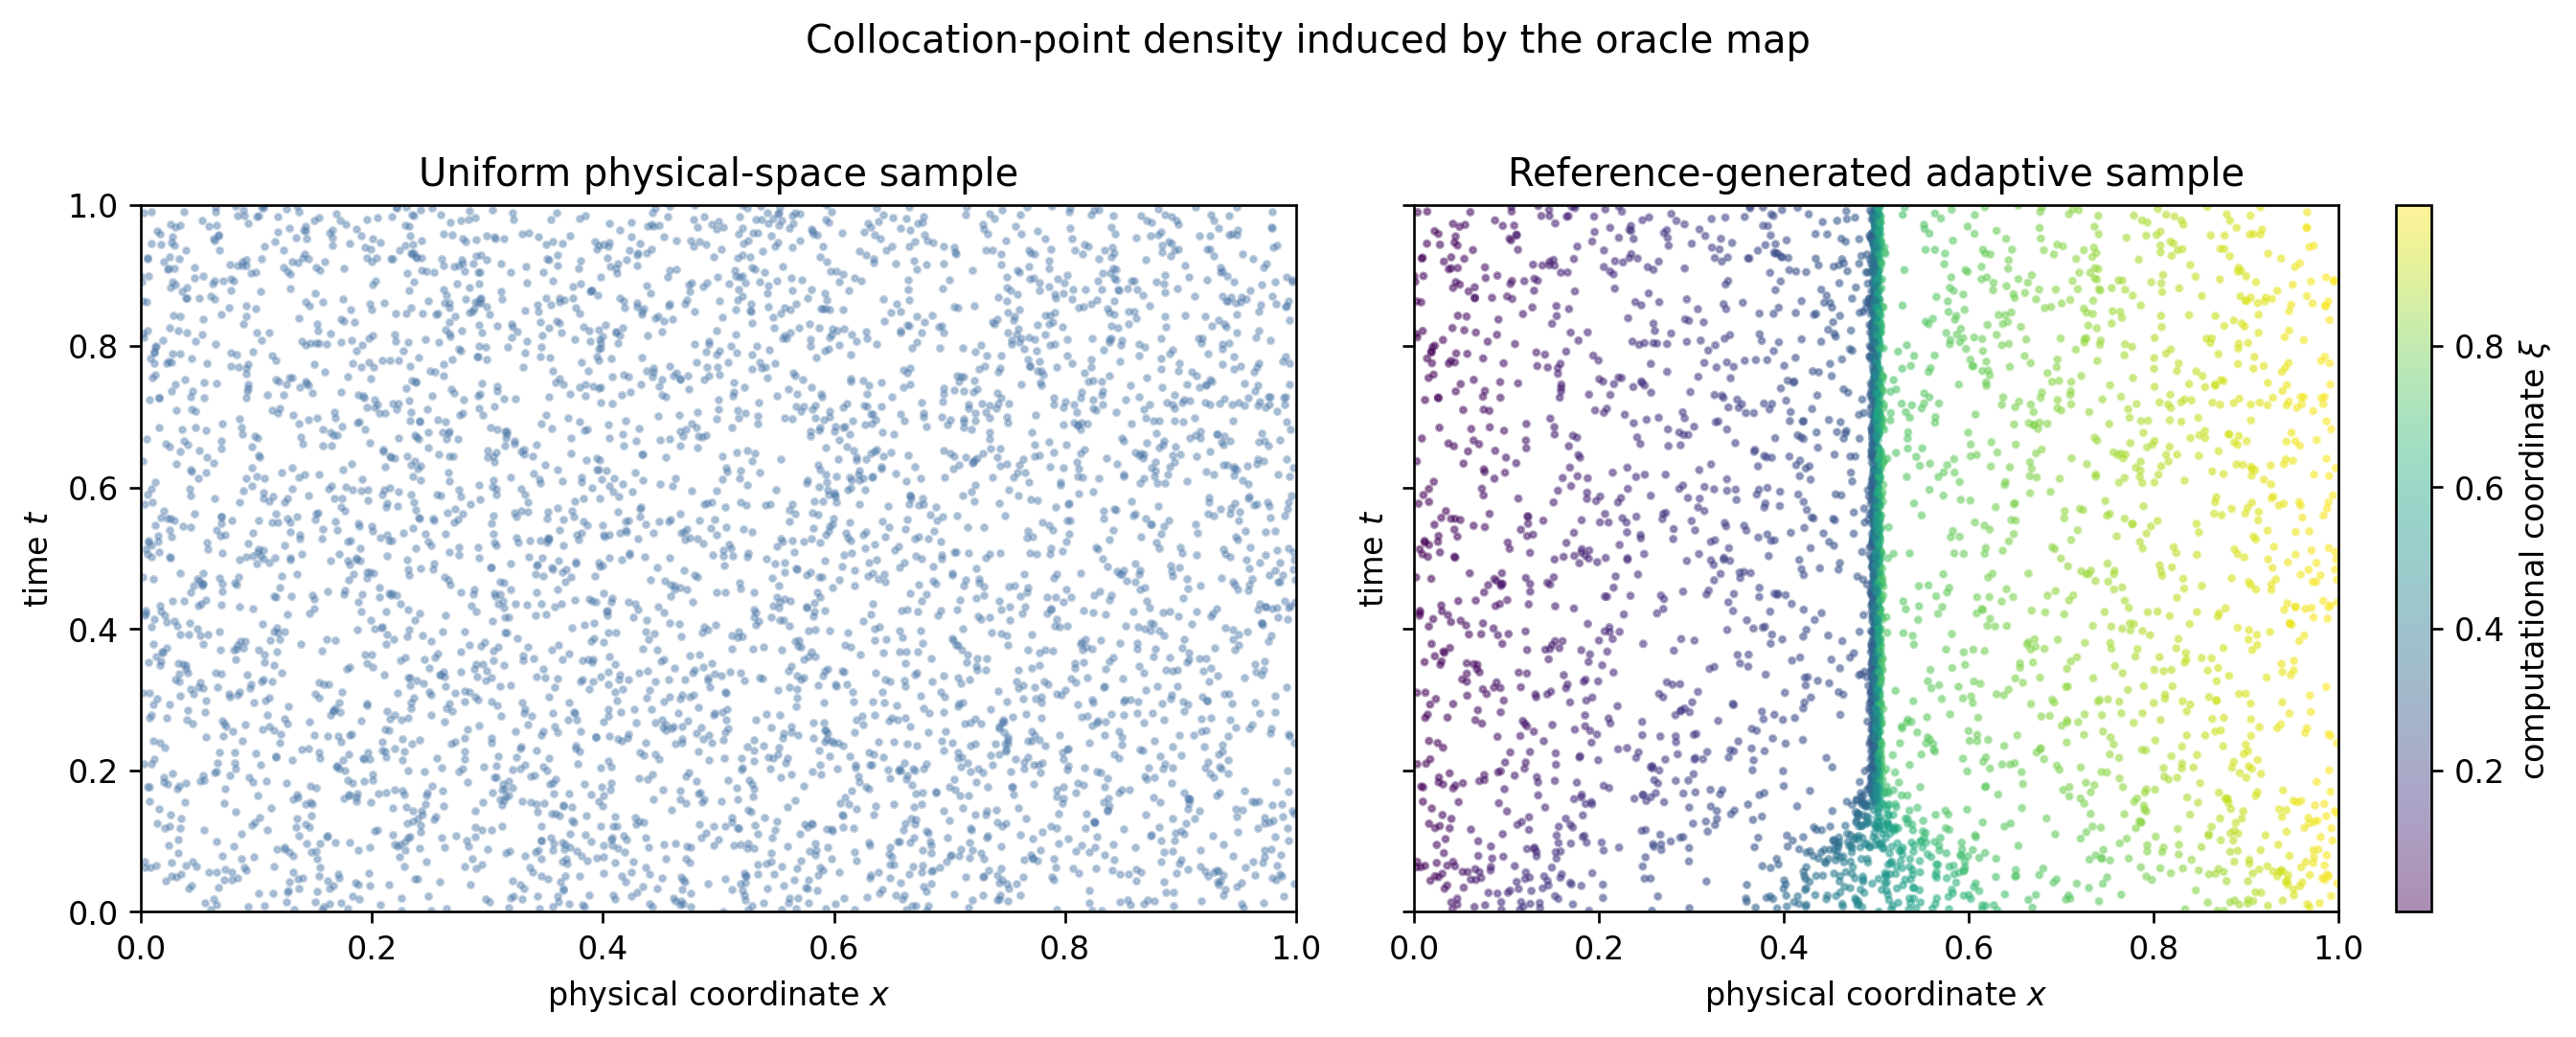

burgers1d_reference_mechanism_final_residual_fields.png


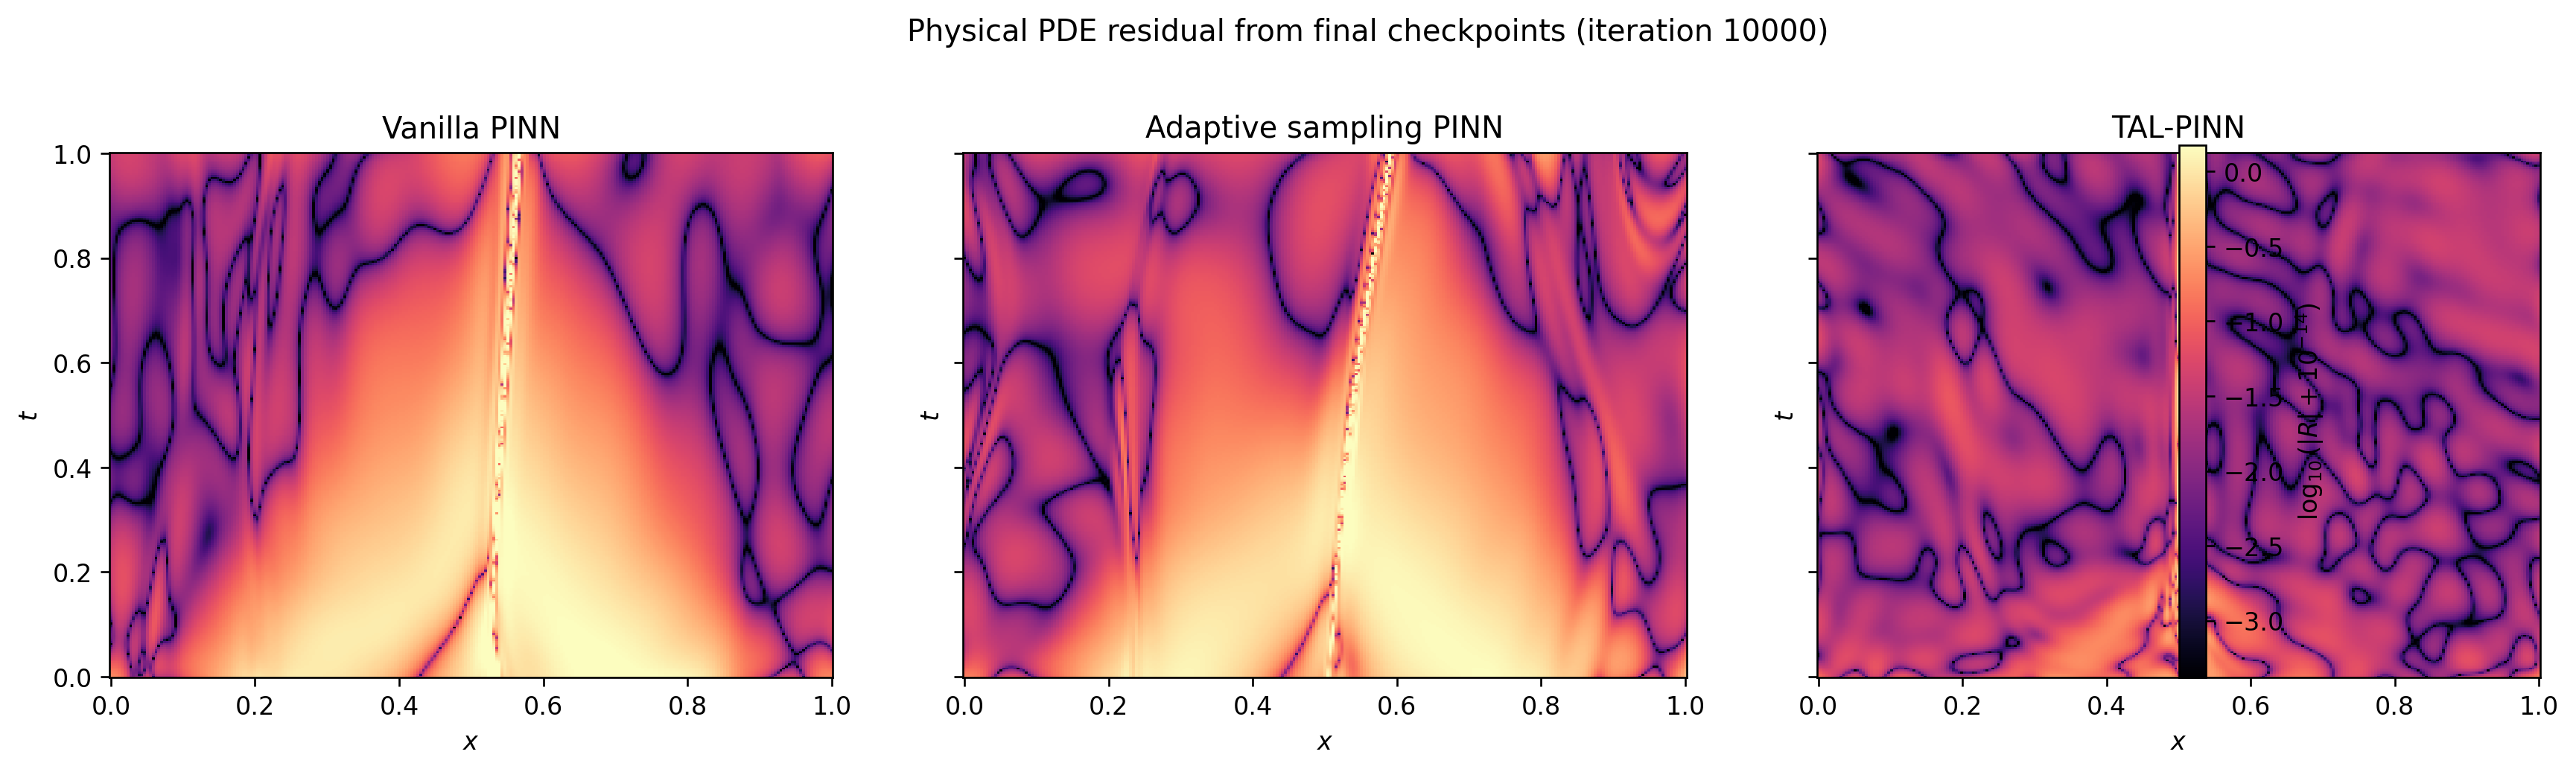

burgers1d_reference_mechanism_sampling_residual_correspondence.png


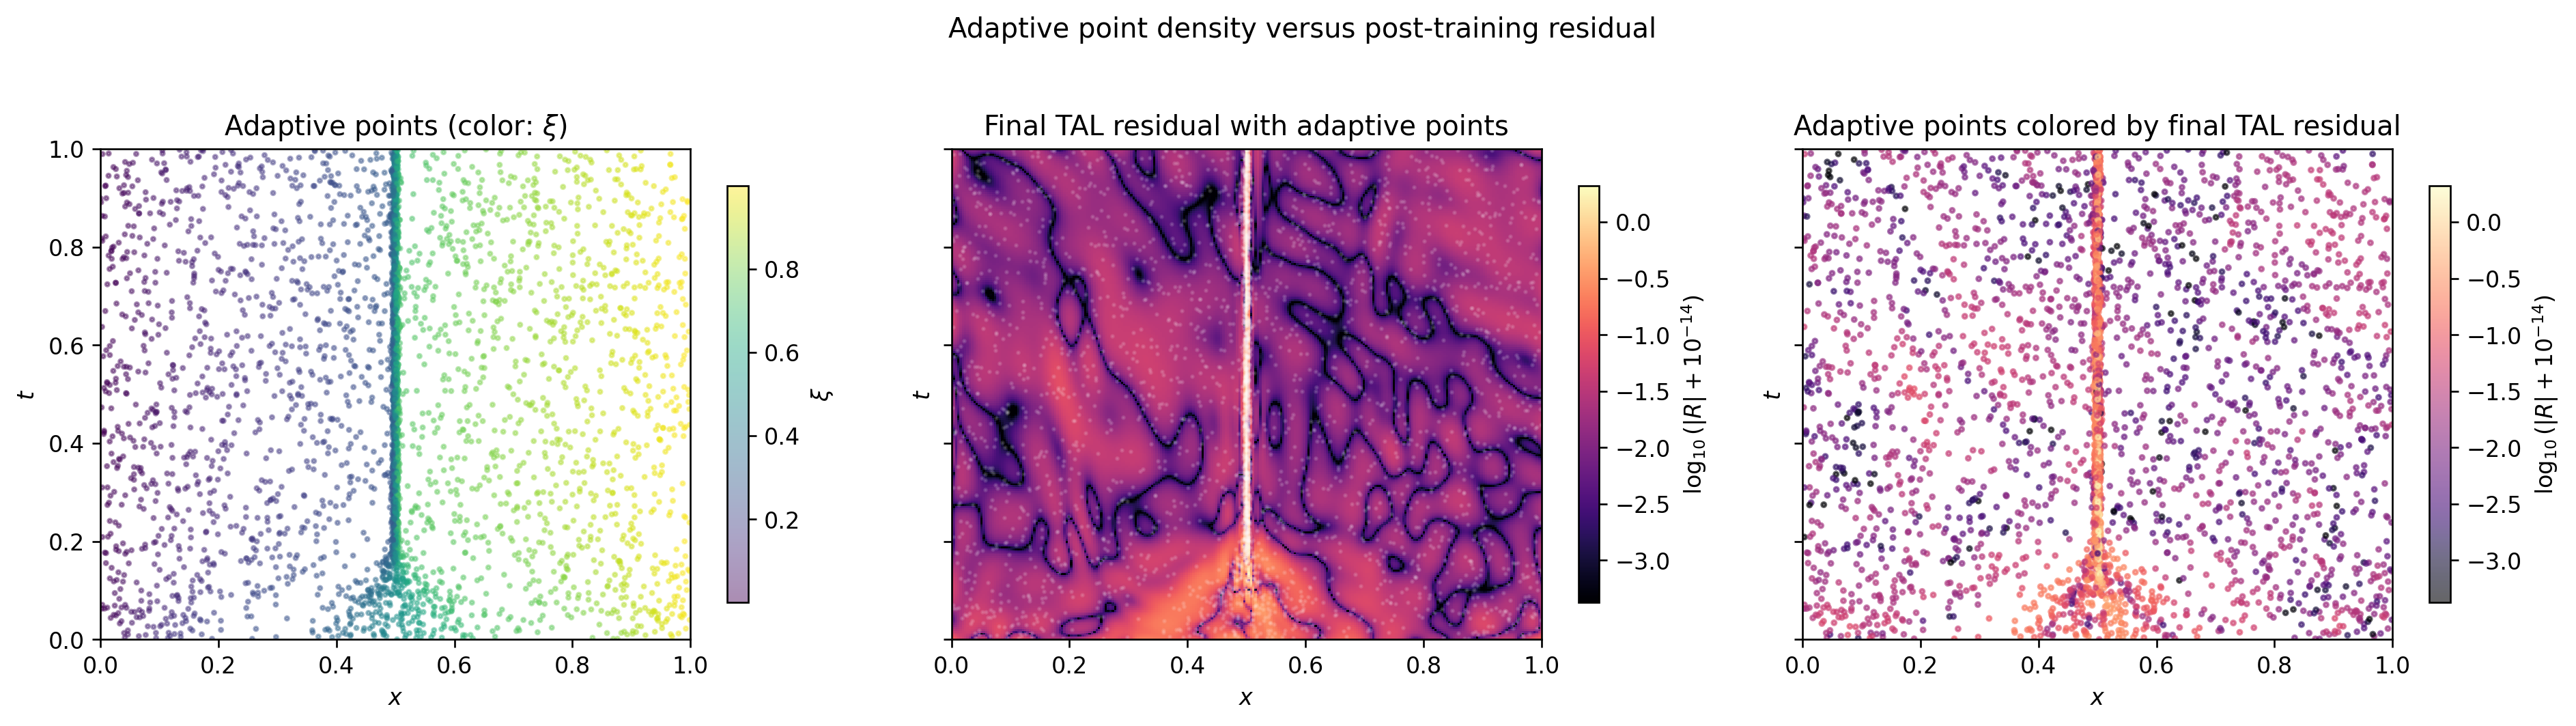

burgers1d_reference_mechanism_ntk_spectra.png


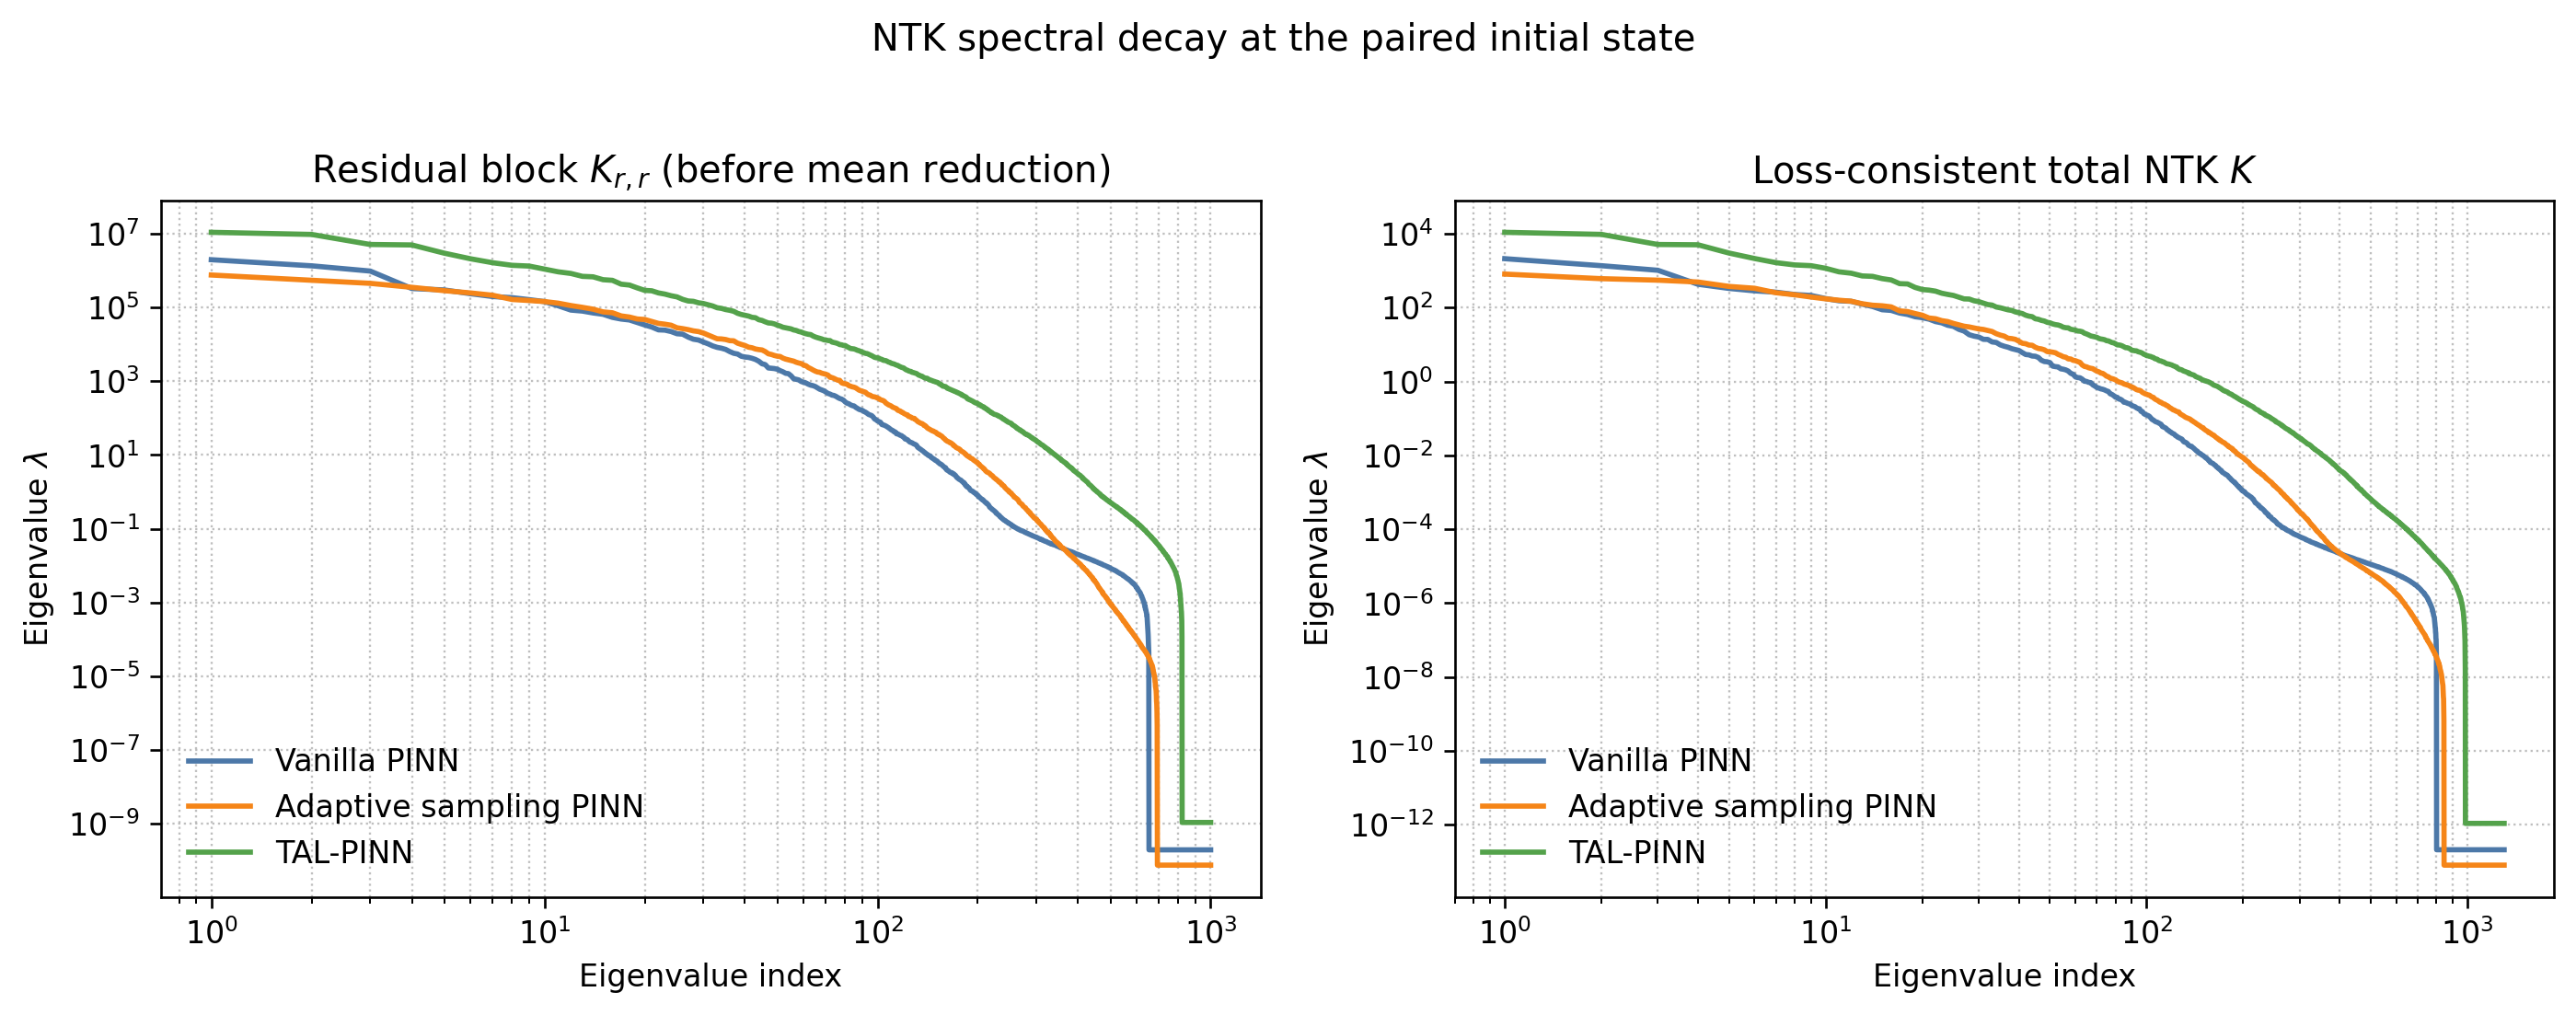

burgers1d_reference_mechanism_loss_history.png


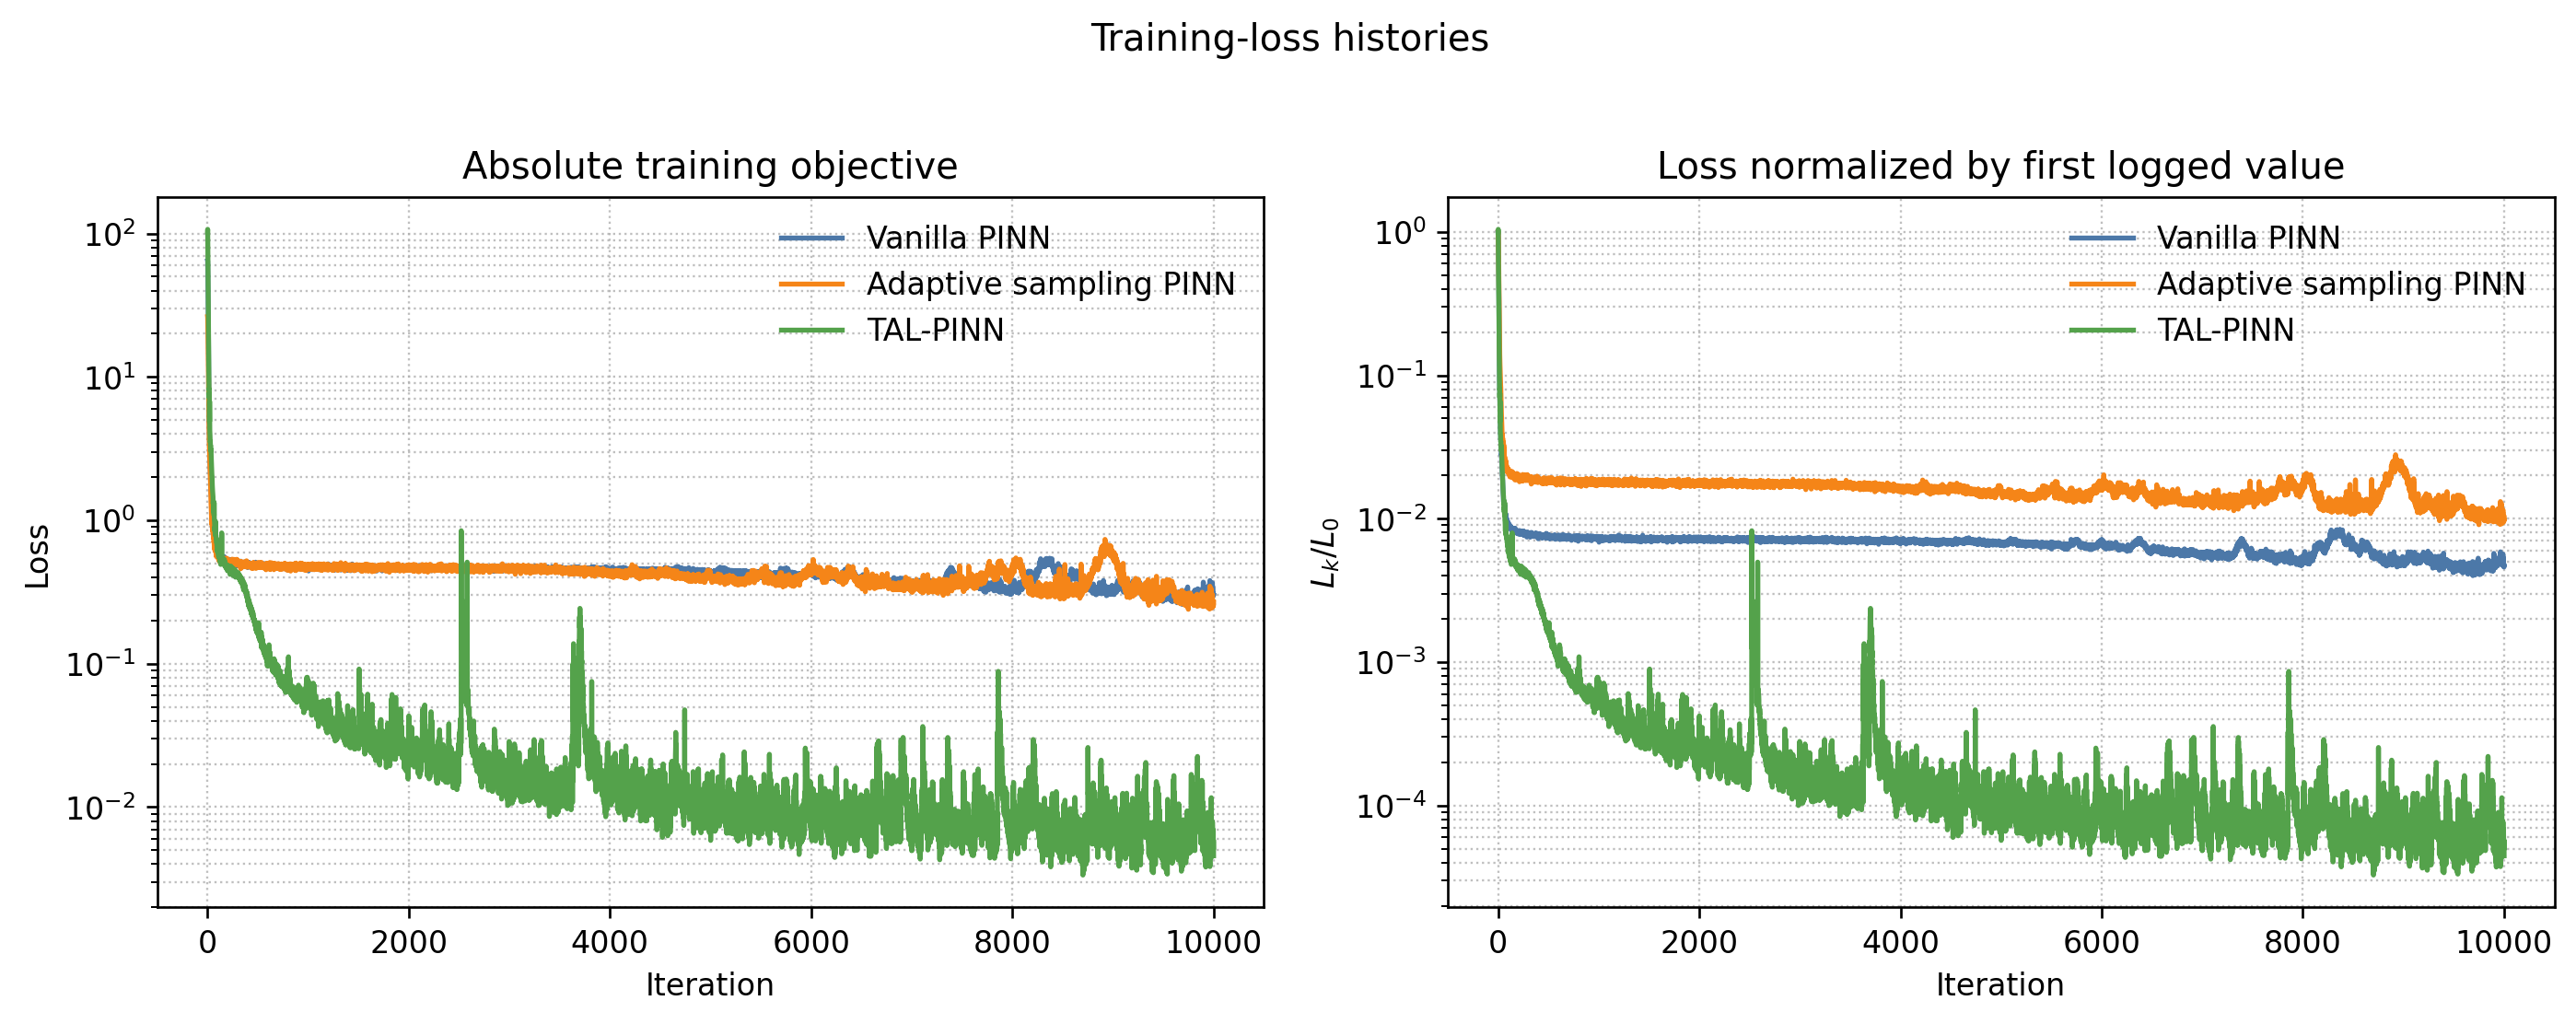

In [18]:
figure_paths = analysis.render_all_figures(export, OUTPUT_PREFIX)
for path in figure_paths:
    path = Path(path)
    if path.suffix.lower() == ".png":
        print(path.name)
        display(Image(filename=str(path)))

In [19]:
analysis.print_final_summary(export)

method                       final loss      final RL2   residual RMS        max |R|
------------------------------------------------------------------------------------
Vanilla PINN               3.005417e-01   5.034983e-01   4.739276e-01   8.383034e+00
Adaptive sampling PINN     2.681043e-01   4.968641e-01   4.500962e-01   9.119179e+00
TAL-PINN                   4.575809e-03   1.527847e-02   5.960700e-02   1.610985e+00
